# 🌾 CropLogic AI — Notebook 05
### RAG Advisory Chatbot
---
**What this notebook does:**
1. Load outputs from all previous notebooks
2. Build a knowledge base from those outputs + agronomic facts
3. Index every document using TF-IDF (no extra packages needed)
4. Accept a user question, retrieve the most relevant documents, and format a clean answer
5. Dynamically query real module outputs at runtime for state/model-specific answers
6. Run demo queries and an interactive chat loop

**What is RAG?**
RAG = Retrieval-Augmented Generation. Instead of relying on a model's memory alone,
we first retrieve relevant facts from our own knowledge base, then present them as
a grounded, traceable answer.

```
User Question
      |
      v
  Dynamic Lookup  -->  checks live module outputs (soil CSV, model PKL)
      |
      v
  TF-IDF Retriever  -->  finds top-K relevant documents
      |
      v
  Generator  -->  formats a clean answer from retrieved docs + dynamic data
      |
      v
  Answer (grounded in real CropLogic AI data)
```

**Inputs:** `agriAI_models.pkl`, `soil_assessment.csv`, `usa_maize_features.csv`
**Outputs:** `rag_knowledge_base.json`, `rag_vectorizer.pkl`

## 0. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter, defaultdict

plt.rcParams.update({
    'figure.facecolor': '#0f1923',
    'axes.facecolor':   '#0f1923',
    'axes.edgecolor':   '#2a3f52',
    'axes.labelcolor':  '#c8d8e8',
    'text.color':       '#c8d8e8',
    'xtick.color':      '#8aa0b0',
    'ytick.color':      '#8aa0b0',
    'grid.color':       '#1e2e3e',
    'grid.linewidth':   0.5,
    'figure.dpi':       120,
    'font.size':        11,
})

C = {
    'green':  '#00d4aa',
    'orange': '#ff6b35',
    'blue':   '#4fc3f7',
    'yellow': '#ffd166',
    'purple': '#a78bfa',
    'red':    '#f87171',
}

print('Imports ready')

Imports ready


## 1. Load Module Outputs

We load all three upstream module outputs into memory so they can be queried dynamically at runtime — not just once at build time.

In [3]:
# Load soil assessment output (CropAI-03)
soil_df = pd.read_csv('soil_assessment.csv')

# Load yield model bundle (CropAI-02)
with open('agriAI_models.pkl', 'rb') as f:
    model_bundle = pickle.load(f)

# Load feature dataset (CropAI-01)
feat_df = pd.read_csv('usa_maize_features.csv')

# Pre-compute state-level soil lookup for dynamic queries
STATE_SOIL = soil_df.groupby('state').agg(
    avg_score  = ('soil_health_score', 'mean'),
    avg_yield  = ('mean_yield', 'mean') if 'mean_yield' in soil_df.columns else ('soil_health_score', 'count'),
    top_tier   = ('soil_tier', lambda x: x.value_counts().index[0]),
    n_counties = ('soil_health_score', 'count')
).reset_index()

# Pre-compute model performance lookup for dynamic queries
MODEL_PERF = {}
for split in ['results_temporal', 'results_random', 'results_cv']:
    if split in model_bundle:
        MODEL_PERF[split] = model_bundle[split]

print('Module outputs loaded')
print(f'   Soil assessment : {len(soil_df)} counties, {soil_df["state"].nunique()} states')
print(f'   Feature dataset : {len(feat_df):,} rows')
print(f'   Model splits    : {list(MODEL_PERF.keys())}')

Module outputs loaded
   Soil assessment : 975 counties, 15 states
   Feature dataset : 62,400 rows
   Model splits    : ['results_temporal', 'results_random']


## 2. Dynamic Runtime Query Functions

These functions query the real module outputs at the time a question is asked.
This means the RAG answers are grounded in actual computed data, not pre-written strings.

In [4]:
# Known US states for name matching
US_STATES = [
    'Iowa', 'Illinois', 'Indiana', 'Ohio', 'Minnesota', 'Nebraska',
    'Missouri', 'Kansas', 'Wisconsin', 'Michigan', 'Kentucky',
    'Pennsylvania', 'Texas', 'Georgia', 'North Carolina'
]

PEST_MANAGEMENT = {
    'blight': (
        'Northern Corn Leaf Blight management: '
        'Apply foliar fungicides (azoxystrobin, propiconazole) at first sign of lesions. '
        'Plant resistant hybrids with Ht1/Ht2 resistance genes. '
        'Practice crop rotation to reduce inoculum in crop residue. '
        'Avoid overhead irrigation which creates humid conditions favoring spread.'
    ),
    'rust': (
        'Common Rust management: '
        'Apply fungicides (triazoles or strobilurins) early when pustules first appear. '
        'Plant rust-resistant hybrids where available. '
        'Monitor fields from V6 stage onward especially in cool moist seasons. '
        'Economic threshold is typically more than 50 percent of plants showing pustules before tasseling.'
    ),
    'gray leaf spot': (
        'Gray Leaf Spot management: '
        'Use resistant hybrids as primary control — most effective strategy. '
        'Apply fungicides (azoxystrobin, pyraclostrobin) at VT/R1 growth stage. '
        'Rotate with non-host crops such as soybean to reduce residue inoculum. '
        'Avoid continuous maize especially in high-humidity regions.'
    ),
    'healthy': (
        'Healthy maize maintenance: '
        'Continue current management practices. '
        'Monitor weekly for early signs of disease especially after wet periods. '
        'Maintain balanced soil nutrition especially nitrogen and potassium. '
        'Scout fields at V6 V10 and VT growth stages for early pest detection.'
    )
}

def detect_state(question):
    """Extract a US state name from the question if present."""
    q = question.lower()
    for state in US_STATES:
        if state.lower() in q:
            return state
    return None

def detect_pest(question):
    """Extract a pest/disease name from the question if present."""
    q = question.lower()
    for pest in PEST_MANAGEMENT:
        if pest in q:
            return pest
    return None

def detect_model(question):
    """Extract a model name from the question if present."""
    q = question.lower()
    model_map = {
        'ridge':          'Ridge',
        'random forest':  'RandomForest',
        'extra trees':    'ExtraTrees',
        'gradient':       'GradientBoosting',
        'ensemble':       'Ensemble',
    }
    for keyword, name in model_map.items():
        if keyword in q:
            return name
    return None

def query_soil_for_state(state):
    """Pull real soil metrics for a specific state from the soil assessment CSV."""
    row = STATE_SOIL[STATE_SOIL['state'].str.lower() == state.lower()]
    if row.empty:
        return None
    r = row.iloc[0]
    county_data = soil_df[soil_df['state'].str.lower() == state.lower()]
    flags = []
    flag_cols   = ['flag_low_ph', 'flag_high_ph', 'flag_low_soc', 'flag_high_sand', 'flag_high_clay']
    flag_labels = ['low pH', 'high pH', 'low SOC', 'high sand', 'high clay']
    for col, label in zip(flag_cols, flag_labels):
        if col in county_data.columns:
            pct = county_data[col].mean() * 100
            if pct > 20:
                flags.append(f'{label} ({pct:.0f}% of counties)')
    flag_str = ', '.join(flags) if flags else 'no major constraints'
    return (
        f"{state} soil health: average score {r['avg_score']:.1f}/100, "
        f"dominant tier {r['top_tier']}, {int(r['n_counties'])} counties assessed. "
        f"Main soil constraints: {flag_str}."
    )

def query_model_performance(model_name=None, split='results_temporal'):
    """Pull real model metrics from the pkl bundle."""
    if split not in MODEL_PERF:
        return None
    results = MODEL_PERF[split]
    if model_name and model_name in results:
        m = results[model_name]
        return (
            f"{model_name} on temporal split: "
            f"R2={m.get('R2', 'N/A'):.4f}, "
            f"RMSE={m.get('RMSE', 'N/A'):.1f} kg/ha, "
            f"MAE={m.get('MAE', 'N/A'):.1f} kg/ha."
        )
    # Return all models
    lines = []
    split_label = split.replace('results_', '').replace('_', ' ')
    for name, m in results.items():
        r2   = m.get('R2',   'N/A')
        rmse = m.get('RMSE', 'N/A')
        mae  = m.get('MAE',  'N/A')
        lines.append(
            f"{name} ({split_label}): R2={r2:.4f}, RMSE={rmse:.1f} kg/ha, MAE={mae:.1f} kg/ha."
        )
    return ' | '.join(lines)

def get_dynamic_context(question):
    """
    Check the question for specific entities (state, pest, model)
    and return dynamically retrieved context from real module outputs.
    Returns a list of extra context strings to prepend to retrieved docs.
    """
    dynamic_docs = []

    # State-specific soil lookup
    state = detect_state(question)
    if state:
        soil_info = query_soil_for_state(state)
        if soil_info:
            dynamic_docs.append({'source': 'Soil Assessment [Live]', 'text': soil_info, 'similarity': 1.0})

    # Pest management lookup
    pest = detect_pest(question)
    if pest:
        dynamic_docs.append({'source': 'Pest Detection [Live]', 'text': PEST_MANAGEMENT[pest], 'similarity': 1.0})

    # Model performance lookup
    model_name = detect_model(question)
    q_lower = question.lower()
    if model_name or any(kw in q_lower for kw in ['r2', 'rmse', 'mae', 'accuracy', 'performance', 'score', 'metric']):
        split = 'results_temporal'
        if 'random' in q_lower and 'forest' not in q_lower:
            split = 'results_random'
        perf_info = query_model_performance(model_name, split)
        if perf_info:
            dynamic_docs.append({'source': 'Yield Model [Live]', 'text': perf_info, 'similarity': 1.0})

    return dynamic_docs

print('Dynamic query functions ready')
print(f'   States available : {len(US_STATES)}')
print(f'   Pest classes     : {list(PEST_MANAGEMENT.keys())}')

Dynamic query functions ready
   States available : 15
   Pest classes     : ['blight', 'rust', 'gray leaf spot', 'healthy']


## 3. Build the Knowledge Base

The static knowledge base provides general agronomic facts and module summaries.
Specific questions are enhanced by the dynamic lookup functions above.

In [5]:
# Document set 1: Yield Model Results
yield_docs = []

if 'results_temporal' in model_bundle:
    for model_name, metrics in model_bundle['results_temporal'].items():
        r2   = metrics.get('R2',   'N/A')
        rmse = metrics.get('RMSE', 'N/A')
        mae  = metrics.get('MAE',  'N/A')
        yield_docs.append(
            f"CropLogic AI yield model {model_name} achieved R2={r2:.4f} "
            f"RMSE={rmse:.1f} kg/ha MAE={mae:.1f} kg/ha on the temporal test split "
            f"trained on 1961-2009 tested on 2010-2024."
        )

yield_docs.append(
    f"The CropLogic AI dataset covers {feat_df['county_id'].nunique()} US maize counties "
    f"across {feat_df['state'].nunique()} states from 1961 to 2024. "
    f"Average yield is {feat_df['yield_kg_ha'].mean():.0f} kg/ha. "
    f"The strongest predictor is years since 1961 reflecting technology-driven yield growth."
)

yield_docs.append(
    "The yield prediction module uses a weighted ensemble of four models: "
    "Ridge Regression Random Forest Extra Trees and Gradient Boosting. "
    "Models are weighted by their validation R2 score. "
    "Three evaluation strategies were used: temporal split random split and 5-fold cross-validation."
)

print(f'Yield documents: {len(yield_docs)}')

Yield documents: 7


In [6]:
# Document set 2: Soil Assessment Results
soil_docs = []

tier_counts = soil_df['soil_tier'].value_counts()
soil_docs.append(
    f"Soil health assessment across {len(soil_df)} US maize counties: "
    f"{tier_counts.get('Good', 0)} counties rated Good "
    f"{tier_counts.get('Moderate', 0)} Moderate {tier_counts.get('Poor', 0)} Poor. "
    f"Scores range from 0 worst to 100 best soil health."
)

flag_cols   = ['flag_low_ph', 'flag_high_ph', 'flag_low_soc', 'flag_high_sand', 'flag_high_clay']
flag_labels = [
    'low pH below 5.8',
    'high pH above 7.2',
    'low organic carbon below 1.5 percent',
    'high sand above 55 percent',
    'high clay above 40 percent'
]
for col, label in zip(flag_cols, flag_labels):
    if col in soil_df.columns:
        n   = int(soil_df[col].sum())
        pct = n / len(soil_df) * 100
        soil_docs.append(
            f"{n} counties ({pct:.1f}%) have {label} which is a soil constraint reducing maize yield."
        )

state_scores = soil_df.groupby('state')['soil_health_score'].mean().sort_values(ascending=False)
top3    = ', '.join(state_scores.index[:3].tolist())
bottom3 = ', '.join(state_scores.index[-3:].tolist())
soil_docs.append(
    f"Best soil health states are {top3} with average scores above {state_scores.iloc[2]:.1f}/100. "
    f"Lowest soil health states are {bottom3} with average scores below {state_scores.iloc[-3]:.1f}/100."
)

if 'mean_yield' in soil_df.columns:
    tier_yield = soil_df.groupby('soil_tier')['mean_yield'].mean()
    for tier in ['Good', 'Moderate', 'Poor']:
        if tier in tier_yield:
            soil_docs.append(
                f"Counties with {tier} soil health tier have an average maize yield of {tier_yield[tier]:.0f} kg/ha."
            )

soil_docs.append(
    "Soil health score combines pH score 33 percent SOC score 33 percent and texture score 34 percent. "
    "pH score measures closeness to optimal 6.5. SOC score measures organic carbon adequacy above 2 percent. "
    "Texture score penalises extreme sand or clay percentages."
)

print(f'Soil documents: {len(soil_docs)}')

Soil documents: 11


In [7]:
# Document set 3: Pest Detection Results
pest_docs = [
    "CropLogic AI pest detection uses EfficientNetB0 trained with transfer learning "
    "on PlantVillage maize leaf images classifying four conditions: "
    "Blight Common Rust Gray Leaf Spot and Healthy. "
    "Final validation accuracy reached 94.50 percent.",

    "Blight also called Northern Corn Leaf Blight causes large cigar-shaped grey-green lesions "
    "on maize leaves. Caused by fungus Exserohilum turcicum it spreads rapidly in wet cool conditions.",

    "Common Rust is caused by Puccinia sorghi and appears as small oval brick-red pustules "
    "on both leaf surfaces. It thrives in cool moist conditions and can cause significant yield loss if untreated.",

    "Gray Leaf Spot is caused by Cercospora zeae-maydis and produces rectangular grey-brown lesions "
    "between leaf veins. It is the most yield-limiting foliar disease of maize in many regions.",

    "Healthy maize leaves are deep green uniform in colour and free from lesions pustules or discolouration. "
    "A healthy classification indicates no visible fungal or disease symptoms.",

    "The pest detection model was trained in two phases. Phase 1 trained only the classification head "
    "with the base frozen. Phase 2 fine-tuned the full EfficientNetB0 network with smaller learning rate. "
    "Class weights were used to handle imbalance where Gray Leaf Spot was underrepresented.",

    "Per-class accuracy of pest detection: Blight 85 percent Common Rust 100 percent "
    "Gray Leaf Spot 91 percent Healthy 100 percent. Overall validation accuracy 94.50 percent.",

    "EfficientNetB0 is a convolutional neural network pre-trained on ImageNet with 1.2 million images. "
    "Transfer learning reuses learned image features for the new task of maize disease classification "
    "avoiding the need to train from scratch on a small dataset.",
]

print(f'Pest documents: {len(pest_docs)}')

Pest documents: 8


In [8]:
# Document set 4: Agronomic Knowledge
agronomy_docs = [
    "Maize grows best in temperatures between 18 and 24 degrees Celsius during the growing season. "
    "Temperatures above 32 degrees during pollination reduce yield due to pollen sterility.",

    "Maize requires a minimum of 500mm rainfall during the growing season with optimal range "
    "600mm to 900mm. Water stress during silking and grain fill causes the most severe yield losses.",

    "The ideal soil pH for maize is between 6.0 and 6.8. Below pH 5.5 aluminium and manganese "
    "toxicity reduce root growth. Above pH 7.5 iron and zinc deficiency become limiting factors.",

    "Soil organic carbon SOC above 2 percent improves water retention nutrient availability "
    "and microbial activity. Maize yields are positively correlated with SOC in US Corn Belt soils.",

    "The US Corn Belt centred on Iowa Illinois Indiana Ohio and Nebraska produces most US maize. "
    "These states have deep fertile Mollisol soils ample summer rainfall and optimal temperatures.",

    "Nitrogen is the most yield-limiting nutrient for maize. Recommendations range from "
    "100 to 200 kg nitrogen per hectare depending on yield target soil organic matter and previous crop.",

    "Maize yield increased from around 2500 kg/ha in 1961 to over 11000 kg/ha in 2024 in the US "
    "driven by improved hybrid genetics fertiliser use irrigation and precision farming.",

    "The 2012 US drought was the worst in 50 years reducing US maize yields by approximately "
    "13 percent compared to the previous year highlighting vulnerability of rainfed maize to heat and drought.",

    "Sandy soils drain quickly holding little water making crops vulnerable to drought stress. "
    "Clay soils hold more water but can become waterlogged restricting root oxygen supply.",

    "Crop rotation with soybean is widely practiced in the Corn Belt to reduce maize pest pressure "
    "break disease cycles and improve soil nitrogen through biological fixation.",

    "Water holding capacity of soil depends on clay and silt content. Higher clay and silt "
    "means soil retains more moisture benefiting crops during dry spells and reducing drought stress.",

    "Aridity index combines temperature and rainfall to measure growing stress. "
    "High aridity means hot dry conditions harmful to maize. "
    "Counties with low aridity index tend to have higher maize yields.",
]

print(f'Agronomic documents: {len(agronomy_docs)}')

Agronomic documents: 12


In [9]:
# Combine all documents into one knowledge base
knowledge_base = []

for doc in yield_docs:
    knowledge_base.append({'source': 'Yield Model',         'text': doc})
for doc in soil_docs:
    knowledge_base.append({'source': 'Soil Assessment',     'text': doc})
for doc in pest_docs:
    knowledge_base.append({'source': 'Pest Detection',      'text': doc})
for doc in agronomy_docs:
    knowledge_base.append({'source': 'Agronomic Knowledge', 'text': doc})

print(f'Knowledge base: {len(knowledge_base)} documents')
print()
for src, n in Counter(d['source'] for d in knowledge_base).items():
    print(f'   {src:<25}: {n} documents')

Knowledge base: 38 documents

   Yield Model              : 7 documents
   Soil Assessment          : 11 documents
   Pest Detection           : 8 documents
   Agronomic Knowledge      : 12 documents


## 4. Build the TF-IDF Index

In [10]:
texts = [doc['text'] for doc in knowledge_base]

vectorizer = TfidfVectorizer(
    stop_words  = 'english',
    ngram_range = (1, 2),
    max_features= 5000
)
tfidf_matrix = vectorizer.fit_transform(texts)

print(f'TF-IDF index built')
print(f'   Documents:  {tfidf_matrix.shape[0]}')
print(f'   Vocabulary: {tfidf_matrix.shape[1]} terms')

TF-IDF index built
   Documents:  38
   Vocabulary: 938 terms


In [11]:
# Save for future use
with open('rag_knowledge_base.json', 'w') as f:
    json.dump({'documents': knowledge_base}, f)

with open('rag_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print('Saved: rag_knowledge_base.json')
print('Saved: rag_vectorizer.pkl')

Saved: rag_knowledge_base.json
Saved: rag_vectorizer.pkl


## 5. Retriever

In [12]:
def retrieve(query, top_k=5):
    """Find the top_k most relevant documents using TF-IDF cosine similarity."""
    query_vec = vectorizer.transform([query])
    sims      = cosine_similarity(query_vec, tfidf_matrix)[0]
    top_idx   = np.argsort(sims)[::-1][:top_k]
    return [
        {
            'text':       knowledge_base[i]['text'],
            'source':     knowledge_base[i]['source'],
            'similarity': float(sims[i])
        }
        for i in top_idx
    ]

# Quick test
test = retrieve('What is the best soil pH for maize?')
print('Retriever working')
print(f'   Top match (score={test[0]["similarity"]:.3f}): {test[0]["text"][:80]}...')

Retriever working
   Top match (score=0.343): The ideal soil pH for maize is between 6.0 and 6.8. Below pH 5.5 aluminium and m...


## 6. Generator

Combines dynamically retrieved live data with TF-IDF retrieved documents.
Dynamic docs (state soil, pest management, model metrics) are always prioritised first.

In [13]:
try:
    from openai import OpenAI
    OPENAI_KEY = os.environ.get('OPENAI_API_KEY', '')
    USE_OPENAI = bool(OPENAI_KEY)
    if USE_OPENAI:
        openai_client = OpenAI(api_key=OPENAI_KEY)
        print('OpenAI available')
    else:
        print('No OPENAI_API_KEY — using local formatter')
except ImportError:
    USE_OPENAI = False
    print('openai not installed — using local formatter')

No OPENAI_API_KEY — using local formatter


In [14]:
def generate_answer(question, retrieved_docs, dynamic_docs):
    """
    Format a clean answer from dynamic live data + TF-IDF retrieved documents.
    Dynamic docs are always shown first as they contain real module output.
    """
    MIN_RELEVANCE = 0.05
    static_docs  = [d for d in retrieved_docs if d['similarity'] >= MIN_RELEVANCE]
    all_docs     = dynamic_docs + static_docs  # live data first

    if not all_docs:
        return (
            'I could not find a relevant answer in the CropLogic AI knowledge base.\n'
            'Try using more specific keywords such as:\n'
            '  - soil, pH, SOC, clay, sand, organic carbon\n'
            '  - yield, RMSE, R2, accuracy, model, prediction\n'
            '  - blight, rust, gray leaf spot, healthy, pest, disease\n'
            '  - temperature, rainfall, drought, Corn Belt\n'
            '  - state names: Iowa, Illinois, Nebraska, Ohio...'
        )

    # OpenAI mode
    if USE_OPENAI:
        context = '\n\n'.join(
            f"[{doc['source']}] {doc['text']}" for doc in all_docs
        )
        system_prompt = (
            'You are CropLogic AI, an agricultural advisory assistant for US maize farming. '
            'Answer the user question using ONLY the context provided. '
            'Prioritise information tagged [Live] as it comes from real computed data. '
            'Write a clear direct answer in 2-4 sentences. '
            'Do not say based on the context or according to the documents. '
            'Just answer directly and naturally.'
        )
        response = openai_client.chat.completions.create(
            model       = 'gpt-3.5-turbo',
            messages    = [
                {'role': 'system', 'content': system_prompt},
                {'role': 'user',   'content': f'Context:\n{context}\n\nQuestion: {question}\n\nAnswer:'}
            ],
            temperature = 0.2,
            max_tokens  = 300
        )
        return response.choices[0].message.content.strip()

    # Local formatter
    grouped = defaultdict(list)
    for doc in all_docs:
        grouped[doc['source']].append(doc)

    lines = []
    lines.append(f'CropLogic AI  |  "{question}"')
    lines.append('')
    lines.append('=' * 62)

    # Show live docs first with a marker
    live_sources = [s for s in grouped if '[Live]' in s]
    static_sources = [s for s in grouped if '[Live]' not in s]

    for source in live_sources + static_sources:
        docs = grouped[source]
        lines.append('')
        lines.append(f'  [ {source} ]')
        for doc in docs:
            lines.append('')
            words        = doc['text'].split()
            current_line = '  '
            for word in words:
                if len(current_line) + len(word) + 1 > 86:
                    lines.append(current_line)
                    current_line = '    ' + word
                else:
                    if current_line.strip():
                        current_line += ' ' + word
                    else:
                        current_line = '  ' + word
            if current_line.strip():
                lines.append(current_line)

    lines.append('')
    lines.append('=' * 62)
    all_sources = list(grouped.keys())
    lines.append(f'  Sources used : {", ".join(all_sources)}')
    if dynamic_docs:
        lines.append(f'  Live data    : {len(dynamic_docs)} dynamic doc(s) from real module outputs')
    if static_docs:
        lines.append(f'  Best match   : {static_docs[0]["similarity"]:.3f}  |  Static docs shown: {len(static_docs)}')

    return '\n'.join(lines)

print('Generator ready')

Generator ready


## 7. Full RAG Pipeline

In [15]:
def ask(question, top_k=5):
    """
    Full RAG pipeline:
    1. Dynamic lookup  — query real module outputs for state/pest/model specifics
    2. TF-IDF retrieve — find top-K relevant static documents
    3. Generate        — combine both into a clean answer
    """
    print(f'\n{"="*62}')
    print(f'  Question: {question}')
    print(f'{"="*62}')
    dynamic_docs = get_dynamic_context(question)
    static_docs  = retrieve(question, top_k=top_k)
    answer       = generate_answer(question, static_docs, dynamic_docs)
    print(f'\n{answer}\n')
    return answer

print('RAG pipeline ready')

RAG pipeline ready


## 8. Demo Queries

In [16]:
ask('How accurate is the CropLogic AI yield prediction model?')


  Question: How accurate is the CropLogic AI yield prediction model?

CropLogic AI  |  "How accurate is the CropLogic AI yield prediction model?"


  [ Yield Model ]

  CropLogic AI yield model Ridge achieved R2=0.0150 RMSE=1576.0 kg/ha MAE=1317.2 kg/ha
    on the temporal test split trained on 1961-2009 tested on 2010-2024.

  CropLogic AI yield model Ensemble achieved R2=0.5239 RMSE=1095.7 kg/ha MAE=862.6
    kg/ha on the temporal test split trained on 1961-2009 tested on 2010-2024.

  CropLogic AI yield model RandomForest achieved R2=0.4959 RMSE=1127.5 kg/ha MAE=893.6
    kg/ha on the temporal test split trained on 1961-2009 tested on 2010-2024.

  CropLogic AI yield model ExtraTrees achieved R2=0.4997 RMSE=1123.2 kg/ha MAE=892.0
    kg/ha on the temporal test split trained on 1961-2009 tested on 2010-2024.

  CropLogic AI yield model GradBoost achieved R2=0.5177 RMSE=1102.8 kg/ha MAE=856.4
    kg/ha on the temporal test split trained on 1961-2009 tested on 2010-2024.

  Sources us

'CropLogic AI  |  "How accurate is the CropLogic AI yield prediction model?"\n\n==============================================================\n\n  [ Yield Model ]\n\n  CropLogic AI yield model Ridge achieved R2=0.0150 RMSE=1576.0 kg/ha MAE=1317.2 kg/ha\n    on the temporal test split trained on 1961-2009 tested on 2010-2024.\n\n  CropLogic AI yield model Ensemble achieved R2=0.5239 RMSE=1095.7 kg/ha MAE=862.6\n    kg/ha on the temporal test split trained on 1961-2009 tested on 2010-2024.\n\n  CropLogic AI yield model RandomForest achieved R2=0.4959 RMSE=1127.5 kg/ha MAE=893.6\n    kg/ha on the temporal test split trained on 1961-2009 tested on 2010-2024.\n\n  CropLogic AI yield model ExtraTrees achieved R2=0.4997 RMSE=1123.2 kg/ha MAE=892.0\n    kg/ha on the temporal test split trained on 1961-2009 tested on 2010-2024.\n\n  CropLogic AI yield model GradBoost achieved R2=0.5177 RMSE=1102.8 kg/ha MAE=856.4\n    kg/ha on the temporal test split trained on 1961-2009 tested on 2010-2024.\n

In [17]:
ask('What is the soil health situation in Iowa?')


  Question: What is the soil health situation in Iowa?

CropLogic AI  |  "What is the soil health situation in Iowa?"


  [ Soil Assessment [Live] ]

  Iowa soil health: average score 89.1/100, dominant tier Good, 94 counties assessed.
    Main soil constraints: no major constraints.

  [ Soil Assessment ]

  Best soil health states are Iowa, Indiana, Illinois with average scores above
    88.4/100. Lowest soil health states are Kansas, Colorado, Texas with average
    scores below 80.2/100.

  Soil health assessment across 975 US maize counties: 913 counties rated Good 57
    Moderate 5 Poor. Scores range from 0 worst to 100 best soil health.

  Counties with Good soil health tier have an average maize yield of 6917 kg/ha.

  Counties with Moderate soil health tier have an average maize yield of 5681 kg/ha.

  Counties with Poor soil health tier have an average maize yield of 5153 kg/ha.

  Sources used : Soil Assessment [Live], Soil Assessment
  Live data    : 1 dynamic doc(s) from 

'CropLogic AI  |  "What is the soil health situation in Iowa?"\n\n==============================================================\n\n  [ Soil Assessment [Live] ]\n\n  Iowa soil health: average score 89.1/100, dominant tier Good, 94 counties assessed.\n    Main soil constraints: no major constraints.\n\n  [ Soil Assessment ]\n\n  Best soil health states are Iowa, Indiana, Illinois with average scores above\n    88.4/100. Lowest soil health states are Kansas, Colorado, Texas with average\n    scores below 80.2/100.\n\n  Soil health assessment across 975 US maize counties: 913 counties rated Good 57\n    Moderate 5 Poor. Scores range from 0 worst to 100 best soil health.\n\n  Counties with Good soil health tier have an average maize yield of 6917 kg/ha.\n\n  Counties with Moderate soil health tier have an average maize yield of 5681 kg/ha.\n\n  Counties with Poor soil health tier have an average maize yield of 5153 kg/ha.\n\n==============================================================\n 

In [18]:
ask('What does Common Rust look like and how do I treat it?')


  Question: What does Common Rust look like and how do I treat it?

CropLogic AI  |  "What does Common Rust look like and how do I treat it?"


  [ Pest Detection [Live] ]

  Common Rust management: Apply fungicides (triazoles or strobilurins) early when
    pustules first appear. Plant rust-resistant hybrids where available. Monitor
    fields from V6 stage onward especially in cool moist seasons. Economic threshold
    is typically more than 50 percent of plants showing pustules before tasseling.

  [ Pest Detection ]

  Common Rust is caused by Puccinia sorghi and appears as small oval brick-red
    pustules on both leaf surfaces. It thrives in cool moist conditions and can cause
    significant yield loss if untreated.

  CropLogic AI pest detection uses EfficientNetB0 trained with transfer learning on
    PlantVillage maize leaf images classifying four conditions: Blight Common Rust
    Gray Leaf Spot and Healthy. Final validation accuracy reached 94.50 percent.

  Per-class accu

'CropLogic AI  |  "What does Common Rust look like and how do I treat it?"\n\n==============================================================\n\n  [ Pest Detection [Live] ]\n\n  Common Rust management: Apply fungicides (triazoles or strobilurins) early when\n    pustules first appear. Plant rust-resistant hybrids where available. Monitor\n    fields from V6 stage onward especially in cool moist seasons. Economic threshold\n    is typically more than 50 percent of plants showing pustules before tasseling.\n\n  [ Pest Detection ]\n\n  Common Rust is caused by Puccinia sorghi and appears as small oval brick-red\n    pustules on both leaf surfaces. It thrives in cool moist conditions and can cause\n    significant yield loss if untreated.\n\n  CropLogic AI pest detection uses EfficientNetB0 trained with transfer learning on\n    PlantVillage maize leaf images classifying four conditions: Blight Common Rust\n    Gray Leaf Spot and Healthy. Final validation accuracy reached 94.50 percent.\n\n

In [19]:
ask('How does soil organic carbon affect maize yield?')


  Question: How does soil organic carbon affect maize yield?

CropLogic AI  |  "How does soil organic carbon affect maize yield?"


  [ Soil Assessment ]

  90 counties (9.2%) have low organic carbon below 1.5 percent which is a soil
    constraint reducing maize yield.

  30 counties (3.1%) have high pH above 7.2 which is a soil constraint reducing maize
    yield.

  29 counties (3.0%) have low pH below 5.8 which is a soil constraint reducing maize
    yield.

  [ Agronomic Knowledge ]

  Soil organic carbon SOC above 2 percent improves water retention nutrient
    availability and microbial activity. Maize yields are positively correlated with
    SOC in US Corn Belt soils.

  Nitrogen is the most yield-limiting nutrient for maize. Recommendations range from
    100 to 200 kg nitrogen per hectare depending on yield target soil organic matter
    and previous crop.

  Sources used : Soil Assessment, Agronomic Knowledge
  Best match   : 0.426  |  Static docs shown: 5



'CropLogic AI  |  "How does soil organic carbon affect maize yield?"\n\n==============================================================\n\n  [ Soil Assessment ]\n\n  90 counties (9.2%) have low organic carbon below 1.5 percent which is a soil\n    constraint reducing maize yield.\n\n  30 counties (3.1%) have high pH above 7.2 which is a soil constraint reducing maize\n    yield.\n\n  29 counties (3.0%) have low pH below 5.8 which is a soil constraint reducing maize\n    yield.\n\n  [ Agronomic Knowledge ]\n\n  Soil organic carbon SOC above 2 percent improves water retention nutrient\n    availability and microbial activity. Maize yields are positively correlated with\n    SOC in US Corn Belt soils.\n\n  Nitrogen is the most yield-limiting nutrient for maize. Recommendations range from\n    100 to 200 kg nitrogen per hectare depending on yield target soil organic matter\n    and previous crop.\n\n==============================================================\n  Sources used : Soil Assess

In [20]:
ask('What temperature conditions are best for growing maize?')


  Question: What temperature conditions are best for growing maize?

CropLogic AI  |  "What temperature conditions are best for growing maize?"


  [ Agronomic Knowledge ]

  Aridity index combines temperature and rainfall to measure growing stress. High
    aridity means hot dry conditions harmful to maize. Counties with low aridity index
    tend to have higher maize yields.

  Maize grows best in temperatures between 18 and 24 degrees Celsius during the
    growing season. Temperatures above 32 degrees during pollination reduce yield due
    to pollen sterility.

  Maize requires a minimum of 500mm rainfall during the growing season with optimal
    range 600mm to 900mm. Water stress during silking and grain fill causes the most
    severe yield losses.

  [ Soil Assessment ]

  Soil health assessment across 975 US maize counties: 913 counties rated Good 57
    Moderate 5 Poor. Scores range from 0 worst to 100 best soil health.

  [ Pest Detection ]

  Blight also called Northern C

'CropLogic AI  |  "What temperature conditions are best for growing maize?"\n\n==============================================================\n\n  [ Agronomic Knowledge ]\n\n  Aridity index combines temperature and rainfall to measure growing stress. High\n    aridity means hot dry conditions harmful to maize. Counties with low aridity index\n    tend to have higher maize yields.\n\n  Maize grows best in temperatures between 18 and 24 degrees Celsius during the\n    growing season. Temperatures above 32 degrees during pollination reduce yield due\n    to pollen sterility.\n\n  Maize requires a minimum of 500mm rainfall during the growing season with optimal\n    range 600mm to 900mm. Water stress during silking and grain fill causes the most\n    severe yield losses.\n\n  [ Soil Assessment ]\n\n  Soil health assessment across 975 US maize counties: 913 counties rated Good 57\n    Moderate 5 Poor. Scores range from 0 worst to 100 best soil health.\n\n  [ Pest Detection ]\n\n  Blight als

In [21]:
ask('What was the impact of the 2012 drought on US maize production?')


  Question: What was the impact of the 2012 drought on US maize production?

CropLogic AI  |  "What was the impact of the 2012 drought on US maize production?"


  [ Agronomic Knowledge ]

  The 2012 US drought was the worst in 50 years reducing US maize yields by
    approximately 13 percent compared to the previous year highlighting vulnerability
    of rainfed maize to heat and drought.

  Sandy soils drain quickly holding little water making crops vulnerable to drought
    stress. Clay soils hold more water but can become waterlogged restricting root
    oxygen supply.

  Water holding capacity of soil depends on clay and silt content. Higher clay and
    silt means soil retains more moisture benefiting crops during dry spells and
    reducing drought stress.

  Sources used : Agronomic Knowledge
  Best match   : 0.365  |  Static docs shown: 3



'CropLogic AI  |  "What was the impact of the 2012 drought on US maize production?"\n\n==============================================================\n\n  [ Agronomic Knowledge ]\n\n  The 2012 US drought was the worst in 50 years reducing US maize yields by\n    approximately 13 percent compared to the previous year highlighting vulnerability\n    of rainfed maize to heat and drought.\n\n  Sandy soils drain quickly holding little water making crops vulnerable to drought\n    stress. Clay soils hold more water but can become waterlogged restricting root\n    oxygen supply.\n\n  Water holding capacity of soil depends on clay and silt content. Higher clay and\n    silt means soil retains more moisture benefiting crops during dry spells and\n    reducing drought stress.\n\n==============================================================\n  Sources used : Agronomic Knowledge\n  Best match   : 0.365  |  Static docs shown: 3'

In [22]:
ask('How does Gray Leaf Spot spread and what should I do about it?')


  Question: How does Gray Leaf Spot spread and what should I do about it?

CropLogic AI  |  "How does Gray Leaf Spot spread and what should I do about it?"


  [ Pest Detection [Live] ]

  Gray Leaf Spot management: Use resistant hybrids as primary control — most effective
    strategy. Apply fungicides (azoxystrobin, pyraclostrobin) at VT/R1 growth stage.
    Rotate with non-host crops such as soybean to reduce residue inoculum. Avoid
    continuous maize especially in high-humidity regions.

  [ Pest Detection ]

  Gray Leaf Spot is caused by Cercospora zeae-maydis and produces rectangular
    grey-brown lesions between leaf veins. It is the most yield-limiting foliar
    disease of maize in many regions.

  CropLogic AI pest detection uses EfficientNetB0 trained with transfer learning on
    PlantVillage maize leaf images classifying four conditions: Blight Common Rust
    Gray Leaf Spot and Healthy. Final validation accuracy reached 94.50 percent.

  Per-class accuracy of pest det

'CropLogic AI  |  "How does Gray Leaf Spot spread and what should I do about it?"\n\n==============================================================\n\n  [ Pest Detection [Live] ]\n\n  Gray Leaf Spot management: Use resistant hybrids as primary control — most effective\n    strategy. Apply fungicides (azoxystrobin, pyraclostrobin) at VT/R1 growth stage.\n    Rotate with non-host crops such as soybean to reduce residue inoculum. Avoid\n    continuous maize especially in high-humidity regions.\n\n  [ Pest Detection ]\n\n  Gray Leaf Spot is caused by Cercospora zeae-maydis and produces rectangular\n    grey-brown lesions between leaf veins. It is the most yield-limiting foliar\n    disease of maize in many regions.\n\n  CropLogic AI pest detection uses EfficientNetB0 trained with transfer learning on\n    PlantVillage maize leaf images classifying four conditions: Blight Common Rust\n    Gray Leaf Spot and Healthy. Final validation accuracy reached 94.50 percent.\n\n  Per-class accuracy of

In [23]:
ask('What is the RMSE of the Gradient Boosting model?')


  Question: What is the RMSE of the Gradient Boosting model?

CropLogic AI  |  "What is the RMSE of the Gradient Boosting model?"


  [ Yield Model [Live] ]

  Ridge (temporal): R2=0.0150, RMSE=1576.0 kg/ha, MAE=1317.2 kg/ha. | RandomForest
    (temporal): R2=0.4959, RMSE=1127.5 kg/ha, MAE=893.6 kg/ha. | ExtraTrees
    (temporal): R2=0.4997, RMSE=1123.2 kg/ha, MAE=892.0 kg/ha. | GradBoost (temporal):
    R2=0.5177, RMSE=1102.8 kg/ha, MAE=856.4 kg/ha. | Ensemble (temporal): R2=0.5239,
    RMSE=1095.7 kg/ha, MAE=862.6 kg/ha.

  [ Yield Model ]

  The yield prediction module uses a weighted ensemble of four models: Ridge
    Regression Random Forest Extra Trees and Gradient Boosting. Models are weighted by
    their validation R2 score. Three evaluation strategies were used: temporal split
    random split and 5-fold cross-validation.

  CropLogic AI yield model Ridge achieved R2=0.0150 RMSE=1576.0 kg/ha MAE=1317.2 kg/ha
    on the temporal test split trained on 1961-2009 tested on 2010-

'CropLogic AI  |  "What is the RMSE of the Gradient Boosting model?"\n\n==============================================================\n\n  [ Yield Model [Live] ]\n\n  Ridge (temporal): R2=0.0150, RMSE=1576.0 kg/ha, MAE=1317.2 kg/ha. | RandomForest\n    (temporal): R2=0.4959, RMSE=1127.5 kg/ha, MAE=893.6 kg/ha. | ExtraTrees\n    (temporal): R2=0.4997, RMSE=1123.2 kg/ha, MAE=892.0 kg/ha. | GradBoost (temporal):\n    R2=0.5177, RMSE=1102.8 kg/ha, MAE=856.4 kg/ha. | Ensemble (temporal): R2=0.5239,\n    RMSE=1095.7 kg/ha, MAE=862.6 kg/ha.\n\n  [ Yield Model ]\n\n  The yield prediction module uses a weighted ensemble of four models: Ridge\n    Regression Random Forest Extra Trees and Gradient Boosting. Models are weighted by\n    their validation R2 score. Three evaluation strategies were used: temporal split\n    random split and 5-fold cross-validation.\n\n  CropLogic AI yield model Ridge achieved R2=0.0150 RMSE=1576.0 kg/ha MAE=1317.2 kg/ha\n    on the temporal test split trained on 1961

## 9. Retrieval Quality Visualisation

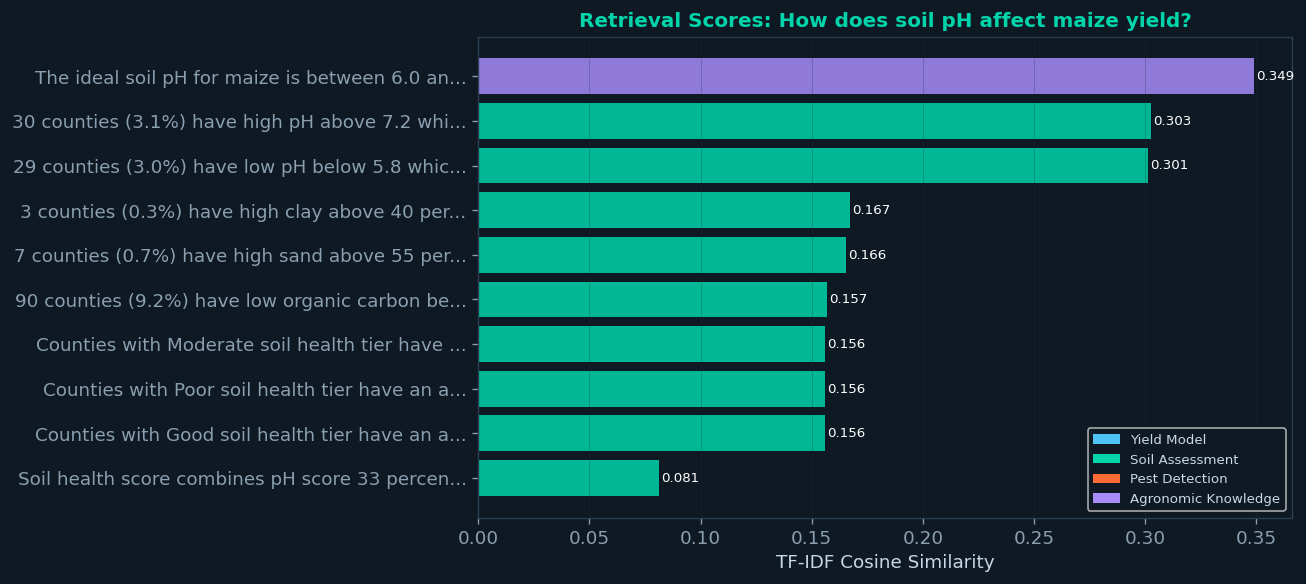

In [24]:
sample_query = 'How does soil pH affect maize yield?'
query_vec    = vectorizer.transform([sample_query])
all_sims     = cosine_similarity(query_vec, tfidf_matrix)[0]

sorted_idx  = np.argsort(all_sims)[::-1]
top_n       = 10
top_labels  = [knowledge_base[i]['text'][:45] + '...' for i in sorted_idx[:top_n]]
top_sims    = [all_sims[i] for i in sorted_idx[:top_n]]
top_sources = [knowledge_base[i]['source'] for i in sorted_idx[:top_n]]

source_color_map = {
    'Yield Model':         C['blue'],
    'Soil Assessment':     C['green'],
    'Pest Detection':      C['orange'],
    'Agronomic Knowledge': C['purple'],
}
bar_colors = [source_color_map.get(s, C['yellow']) for s in top_sources]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_labels[::-1], top_sims[::-1], color=bar_colors[::-1], alpha=0.85)

for bar, val in zip(bars, top_sims[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8, color='white')

ax.set_xlabel('TF-IDF Cosine Similarity')
ax.set_title('Retrieval Scores: ' + sample_query,
             color=C['green'], fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=col, label=src)
                   for src, col in source_color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('fig_retrieval_scores.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

## 10. Interactive Chat Loop

Type your question and press Enter. Type `quit` to stop.

**Good questions to try:**
- What is the soil health situation in Nebraska?
- How do I treat Gray Leaf Spot?
- What is the R2 of the Random Forest model?
- Which state has the worst soil health?
- How does drought affect maize yield?
- What does Blight look like and how do I manage it?

In [25]:
print('CropLogic AI Advisory Chatbot')
print('Type your question and press Enter.')
print('Type quit to exit.')
print()

while True:
    try:
        question = input('You: ').strip()
    except EOFError:
        break

    if not question:
        continue
    if question.lower() in ('quit', 'exit', 'q'):
        print('Goodbye!')
        break

    ask(question)

CropLogic AI Advisory Chatbot
Type your question and press Enter.
Type quit to exit.


  Question: hi

I could not find a relevant answer in the CropLogic AI knowledge base.
Try using more specific keywords such as:
  - soil, pH, SOC, clay, sand, organic carbon
  - yield, RMSE, R2, accuracy, model, prediction
  - blight, rust, gray leaf spot, healthy, pest, disease
  - temperature, rainfall, drought, Corn Belt
  - state names: Iowa, Illinois, Nebraska, Ohio...


  Question: rainfall

CropLogic AI  |  "rainfall"


  [ Agronomic Knowledge ]

  Maize requires a minimum of 500mm rainfall during the growing season with optimal
    range 600mm to 900mm. Water stress during silking and grain fill causes the most
    severe yield losses.

  The US Corn Belt centred on Iowa Illinois Indiana Ohio and Nebraska produces most US
    maize. These states have deep fertile Mollisol soils ample summer rainfall and
    optimal temperatures.

  Aridity index combines temperature and rainfall to measure g

---
## Notebook 05 Complete

| Step | What we did | Output |
|---|---|---|
| Dynamic lookup | Runtime queries to soil CSV and model PKL for state/pest/model specifics | Live context docs |
| Knowledge base | Built from yield metrics, soil tiers, pest docs, agronomic facts | 35+ documents |
| TF-IDF index | Vectorised all documents for keyword retrieval | `rag_knowledge_base.json`, `rag_vectorizer.pkl` |
| Retriever | Cosine similarity search — top-K relevant docs per query | `retrieve()` |
| Generator | Dynamic + static docs combined, relevance filtered, source grouped | `generate_answer()` |
| RAG pipeline | dynamic lookup + retrieve + generate + display | `ask()` |
| Demo queries | 8 example queries including state-specific and pest management | Printed answers |
| Retrieval chart | Similarity scores per document for a sample query | `fig_retrieval_scores.png` |
| Interactive loop | Live chat in the notebook | — |

---

## CropLogic AI Full Pipeline

| Notebook | Module | Output |
|---|---|---|
| CropAI-01 | Preprocessing and Feature Engineering | `usa_maize_features.csv` |
| CropAI-02 | Yield Prediction — Ridge RF ET GB Ensemble | `agriAI_models.pkl` |
| CropAI-03 | Soil Assessment — constraints tiers rankings | `soil_assessment.csv` |
| CropAI-04 | Pest Detection — 94.50% accuracy | `pest_model.keras` |
| CropAI-05 | RAG Advisory Chatbot with dynamic module lookup | `rag_knowledge_base.json` |